In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
from sklearn.metrics import cohen_kappa_score

Reports generated by two systems

T1, T2, T3, T4, T5

G1, G2, G3, G4, G5

Two survey links

Survey n°1: T1 (1), G2 (4), T3 (5), G4 (8), T5 (9) => v1

Survey n°2: T2 (3), G1 (2), G3 (6), T4 (7), G5 (10) => v2

10 questions for each report


***check if 5 is always better in the 9 questions*** => yes

R1Q1. Le rapport vous paraît-il fluide ? 
4 : plutôt fluide

R1Q2. Le rapport est-il concis ? 
 5 : parfaitement concis
 
R1Q3. Les informations données dans le rapport sont-elles pertinentes ? 
 4 : plutôt pertinentes
 
R1Q4. Le rapport vous parait-il cohérent ? 
4 : plutôt cohérent

R1Q5. Le rapport fournit-il des informations pertinentes sur le déroulement de la séance ? Indiquez toute information qui vous semblerait pertinente à ajouter. 
4 : plutôt pertinent

R1Q6. Est-ce que le rapport semble bien décrire les états affectifs exprimés par le participant au cours de la séance. 
 3 : plus ou moins décrit  5 : parfaitement décrit
 
R1Q7. Est-ce que les résultats des exercices sont présentés de façon claire ? 
 5 : parfaitement claire
 
R1Q8. Le rapport précise-t-il les fonctions cognitives et permet-il d'évaluer les fonctions cognitives du patient pendant la séance ? 
 3 : plus ou moins précis 4 : plutôt précis
 
R1Q9. Les indicateurs linguistiques présentés dans le rapport sont-ils utiles ?  
4 : plutôt utiles

In [380]:
# Preprocess the values (convert to integers in this example)
def preprocess_value(value):
    try:
        value_int = int(value.split(" :")[0])
        return value_int
    except ValueError:
        return value

In [404]:
def preprocess_eval_csv(file):
    df_eval_result = pd.read_csv(file)
    # Keep only fully completed responses, delete rows with “NaN” in "submitdate. Date de soumission"
    df_eval_result_completed = df_eval_result[df_eval_result['submitdate. Date de soumission'].notna()]
    # df_eval_result_completed = df_eval_result.dropna(subset=['submitdate. Date de soumission'])
    # Filter columns that start with 'R1' and exclude those containing '[comment]' or 'Time'
    columns_to_extract = [
        col for col in df_eval_result_completed.columns
        if col.startswith('R') and '[comment]' not in col and 'Time' not in col and 'Q10' not in col
    ]

    columns_to_extract.append("token. Code d'accès")

    # extracted_columns = df_eval_result_v1_completed[columns_to_extract]
    extracted_columns = df_eval_result_completed.loc[:, columns_to_extract].copy()

    # Apply preprocessing to the extracted columns
    for column in extracted_columns.columns:
        # print(column)
        extracted_columns[column] = extracted_columns[column].apply(preprocess_value)

    extracted_columns.rename(columns=lambda x: x.split(".")[0], inplace=True)
    return extracted_columns
    

In [ ]:
def seperate_df(df):
    """Separate DataFrame into 5 DataFrames based on R1-R5 prefixes with renamed columns."""
    
    # Define prefixes
    prefixes = ['R1', 'R2', 'R3', 'R4', 'R5']
    
    # Create and return DataFrames directly
    result_dfs = []
    for prefix in prefixes:
        filtered_df = df.filter(like=prefix)
        # Rename columns to Q1, Q2, Q3, etc.
        new_columns = {old_col: f'Q{idx+1}' for idx, old_col in enumerate(filtered_df.columns)}
        renamed_df = filtered_df.rename(columns=new_columns)
        result_dfs.append(renamed_df)
    
    return tuple(result_dfs)

In [ ]:
# Create a dictionary for renaming the columns
rename_dict = {
    'Q1': 'Fluidity',
    'Q2': 'Conciseness',
    'Q3': 'Relevance', # pertinentes
    'Q4': 'Coherence',
    'Q5': 'Session Info',
    'Q6': 'Affective States',
    'Q7': 'Results',
    'Q8': 'Cognitive Functions',
    'Q9': 'Linguistic Indicators'
}

df_v1_extracted = preprocess_eval_csv("./results-survey728958_anonymized.csv")
df_v2_extracted = preprocess_eval_csv("./results-survey589241_anonymized.csv")

def get_results(results_presentation):
    if results_presentation == "orthoAndstudent":
        V1R1, V1R2, V1R3, V1R4, V1R5 = seperate_df(df_v1_extracted)
        V2R1, V2R2, V2R3, V2R4, V2R5 = seperate_df(df_v2_extracted)
    elif results_presentation == "ortho":
        df_ortho_v1, df_student_v1 = seperate_df_by_expertise(df_v1_extracted)
        df_ortho_v2, df_student_v2 = seperate_df_by_expertise(df_v2_extracted)
        V1R1, V1R2, V1R3, V1R4, V1R5 = seperate_df(df_ortho_v1)
        V2R1, V2R2, V2R3, V2R4, V2R5 = seperate_df(df_ortho_v2)
    elif results_presentation == "student":
        df_ortho_v1, df_student_v1 = seperate_df_by_expertise(df_v1_extracted)
        df_ortho_v2, df_student_v2 = seperate_df_by_expertise(df_v2_extracted)
        V1R1, V1R2, V1R3, V1R4, V1R5 = seperate_df(df_student_v1)
        V2R1, V2R2, V2R3, V2R4, V2R5 = seperate_df(df_student_v2)
    
    dfs_GPT4 = pd.concat([V1R2, V1R4, V2R2, V2R3, V2R5], axis=0)
    dfs_template = pd.concat([V1R1, V1R3, V1R5, V2R1, V2R4], axis=0)
    
    # # Add identifier column to each DataFrame
    # dfs_GPT4['Group'] = 'GPT4'
    # dfs_template['Group'] = 'Template'

    # Concatenate the DataFrames
    # df_combined = pd.concat([dfs_GPT4, dfs_template])
    dfs_GPT4 = dfs_GPT4.rename(columns=rename_dict)
    dfs_template = dfs_template.rename(columns=rename_dict)

    columns_to_sum = dfs_GPT4.columns #[:-1]
    print(columns_to_sum)

    dfs_GPT4["Overall"] = round(dfs_GPT4[columns_to_sum].sum(axis=1)/9, 2)
    dfs_template["Overall"] = round(dfs_template[columns_to_sum].sum(axis=1)/9, 2)
    
    average_list_GPT4, std_list_GPT4 = get_average(dfs_GPT4)
    # print(average_list_GPT4, std_list_GPT4)
    average_list_template, std_list_template = get_average(dfs_template)
    # print(average_list_template, std_list_template)
    
    results_GPT4 = ["{}({})".format(a_, b_) for a_, b_ in zip(average_list_GPT4, std_list_GPT4)]
    results_template = ["{}({})".format(a_, b_) for a_, b_ in zip(average_list_template, std_list_template)]
    return results_GPT4, results_template

In [422]:
results_GPT4, results_template = get_results("orthoAndstudent")
print("results_template:", results_template)
print("results_GPT4:", results_GPT4)

Index(['Fluidity', 'Conciseness', 'Relevance', 'Coherence', 'Session Info',
       'Affective States', 'Results', 'Cognitive Functions',
       'Linguistic Indicators'],
      dtype='object')
results_template: ['4.5(0.61)', '4.15(1.18)', '3.85(1.04)', '4.25(0.72)', '3.65(0.81)', '3.6(0.94)', '4.45(0.94)', '3.5(1.19)', '3.25(1.52)', '3.91(0.65)']
results_GPT4: ['3.65(1.27)', '4.7(0.47)', '3.9(0.97)', '3.85(0.88)', '3.45(1.0)', '3.7(1.13)', '3.7(1.3)', '3.45(1.0)', '3.85(1.27)', '3.81(0.75)']


In [423]:
results_GPT4, results_template = get_results("ortho")
print("results_template:", results_template)
print("results_GPT4:", results_GPT4)

Index(['Fluidity', 'Conciseness', 'Relevance', 'Coherence', 'Session Info',
       'Affective States', 'Results', 'Cognitive Functions',
       'Linguistic Indicators'],
      dtype='object')
results_template: ['4.5(0.53)', '4.8(0.42)', '4.2(1.14)', '4.4(0.7)', '3.8(1.03)', '3.9(0.99)', '4.2(1.23)', '3.6(1.26)', '3.4(1.71)', '4.09(0.75)']
results_GPT4: ['3.2(1.23)', '4.7(0.48)', '3.8(1.23)', '3.5(1.08)', '3.3(1.06)', '3.7(1.25)', '3.5(1.35)', '3.5(0.85)', '3.6(1.51)', '3.64(0.93)']


In [424]:
results_GPT4, results_template = get_results("student")
print("results_template:", results_template)
print("results_GPT4:", results_GPT4)

Index(['Fluidity', 'Conciseness', 'Relevance', 'Coherence', 'Session Info',
       'Affective States', 'Results', 'Cognitive Functions',
       'Linguistic Indicators'],
      dtype='object')
results_template: ['4.5(0.71)', '3.5(1.35)', '3.5(0.85)', '4.1(0.74)', '3.5(0.53)', '3.3(0.82)', '4.7(0.48)', '3.4(1.17)', '3.1(1.37)', '3.73(0.52)']
results_GPT4: ['4.1(1.2)', '4.7(0.48)', '4.0(0.67)', '4.2(0.42)', '3.6(0.97)', '3.7(1.06)', '3.9(1.29)', '3.4(1.17)', '4.1(0.99)', '3.97(0.5)']


## Participant Information (Anonymized)

**V1 Survey Participants:**
- P1: Professional orthophonist - Token: pOGfluuQWXJiioD
- P2: Final year student - Token: hORPh8vuhnCzGZY  
- P3: 4th year student - Token: 4WYa4GHRXCOZ769
- P4: Professional orthophonist (graduated 2022) - Token: iOi6dDn5FFMsvWl

**V2 Survey Participants:**
- P5: Final year student - Token: F638tvJl6Ur7Kng
- P6: 4th year student - Token: NJSzpNcltsXlNnu
- P7: Professional orthophonist - Token: G2Os9GI5aaHFXtl
- P8: Professional orthophonist (9 months experience) - Token: TXaPREUvuwcXQOC

**Categories:**
- Professional orthophonists: 4 participants
- Students (4th-final year): 4 participants

In [391]:
def seperate_df_by_expertise(df):
    token_values_ortho = ["pOGfluuQWXJiioD", "iOi6dDn5FFMsvWl", "G2Os9GI5aaHFXtl", "TXaPREUvuwcXQOC"]
    token_values_student = ["hORPh8vuhnCzGZY", "4WYa4GHRXCOZ769", "F638tvJl6Ur7Kng", "NJSzpNcltsXlNnu"]

    df_ortho = df[df['token'].isin(token_values_ortho)]
    df_student = df[df['token'].isin(token_values_student)]

    return df_ortho, df_student

In [388]:
df_v1_extracted

,R1Q1,R1Q2,R1Q3,R1Q4,R1Q5,R1Q6,R1Q7,R1Q8,R1Q9,R2Q1,...,R5Q1,R5Q2,R5Q3,R5Q4,R5Q5,R5Q6,R5Q7,R5Q8,R5Q9,token
1,4,5,4,4,4,3,5,3,4,4,...,4,5,5,5,4,5,5,4,4,pOGfluuQWXJiioD
2,5,5,3,5,4,2,5,2,1,4,...,4,4,4,4,4,4,5,2,2,4WYa4GHRXCOZ769
4,4,2,2,3,3,4,4,4,3,5,...,3,2,3,3,3,3,4,3,3,hORPh8vuhnCzGZY
5,4,5,2,5,4,3,2,2,1,2,...,5,5,3,4,2,2,2,2,1,iOi6dDn5FFMsvWl


In [392]:
df_ortho_v1, df_student_v1 = seperate_df_by_expertise(df_v1_extracted)
df_ortho_v1

,R1Q1,R1Q2,R1Q3,R1Q4,R1Q5,R1Q6,R1Q7,R1Q8,R1Q9,R2Q1,...,R5Q1,R5Q2,R5Q3,R5Q4,R5Q5,R5Q6,R5Q7,R5Q8,R5Q9,token
1,4,5,4,4,4,3,5,3,4,4,...,4,5,5,5,4,5,5,4,4,pOGfluuQWXJiioD
5,4,5,2,5,4,3,2,2,1,2,...,5,5,3,4,2,2,2,2,1,iOi6dDn5FFMsvWl


In [393]:
df_ortho_v2, df_student_v2 = seperate_df_by_expertise(df_v2_extracted)
df_ortho_v2

,R1Q1,R1Q2,R1Q3,R1Q4,R1Q5,R1Q6,R1Q7,R1Q8,R1Q9,R2Q1,...,R5Q1,R5Q2,R5Q3,R5Q4,R5Q5,R5Q6,R5Q7,R5Q8,R5Q9,token
1,5,4,5,4,4,4,5,4,5,4,...,3,5,5,4,4,5,2,4,5,G2Os9GI5aaHFXtl
8,5,5,5,5,4,5,5,5,4,3,...,2,4,3,3,3,4,2,4,4,TXaPREUvuwcXQOC


In [389]:
V1R1

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9
1,4,5,4,4,4,3,5,3,4
2,5,5,3,5,4,2,5,2,1
4,4,2,2,3,3,4,4,4,3
5,4,5,2,5,4,3,2,2,1


In [370]:
dfs_GPT4 = pd.concat([V1R2, V1R4, V2R2, V2R3, V2R5], axis=0)
dfs_template = pd.concat([V1R1, V1R3, V1R5, V2R1, V2R4], axis=0)

In [353]:
dfs_GPT4

,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9
1,4,5,5,5,4,5,5,4,3
2,4,5,4,4,5,5,5,2,2
4,5,4,3,4,2,4,3,3,4
5,2,5,2,2,1,2,2,2,1
1,5,5,5,5,4,4,4,4,4
2,4,4,4,4,5,5,2,2,4
4,4,5,4,4,3,3,4,3,4
5,1,5,2,2,2,2,2,2,1
0,5,5,4,5,4,2,5,5,5
1,4,5,4,4,4,4,5,4,5


In [411]:
def get_average(df):
    average_list = []
    std_list = []
    for m in df.columns:
        aver = round(df[m].mean(), 2)
        average_list.append(aver)
        std = round(df[m].std(), 2)
        std_list.append(std)
    return average_list, std_list

In [ ]:
results_list = [results_template, results_GPT4]
table_data = pd.DataFrame(results_list)
 
# add columns
table_data.columns = dfs_GPT4.columns # changed the model names
table_data.index = ['Template', 'GPT4']

table_data

,Fluidity,Conciseness,Relevance,Coherence,Session Info,Affective States,Results,Cognitive Functions,Linguistic Indicators,Overall
Template,4.5(0.61),4.15(1.18),3.85(1.04),4.25(0.72),3.65(0.81),3.6(0.94),4.45(0.94),3.5(1.19),3.25(1.52),3.91(0.65)
GPT4,3.65(1.27),4.7(0.47),3.9(0.97),3.85(0.88),3.45(1.0),3.7(1.13),3.7(1.3),3.45(1.0),3.85(1.27),3.81(0.75)


In [362]:
average_list = [average_list_template, average_list_GPT4]
data = pd.DataFrame(average_list)
 
# add columns
data.columns = dfs_GPT4.columns # changed the model names
data.index = ['Template', 'GPT4']

data

,Fluidity,Conciseness,Relevance,Coherence,Session Info,Affective States,Results,Cognitive Functions,Linguistic Indicators,Overall
Template,4.50,4.15,3.85,4.25,3.65,3.6,4.45,3.50,3.25,3.91
GPT4,3.65,4.70,3.90,3.85,3.45,3.7,3.70,3.45,3.85,3.81


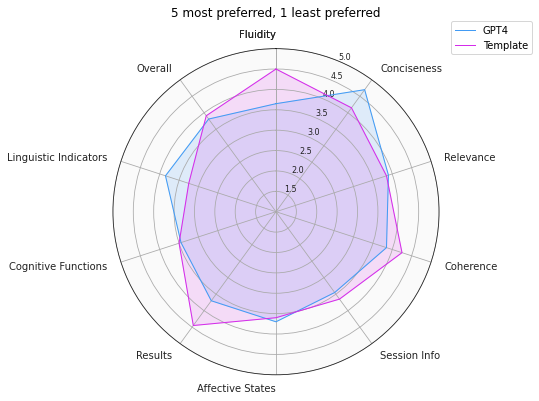

In [ ]:
# Each attribute we'll plot in the radar chart.
cat = data.columns.tolist()
cat += cat[:1]  #to close the radar, duplicate the first column
n_points = len(cat)

#As we have 5 categories the radar chart shoud have 5 radial axis
# To find out the angle of each quadrant we divide 360/5 = 72 degrees
#angles need to be converted to radian so we multiply by 2*pi and create the list of angles:
label_loc = np.linspace(start=0, stop=2 * np.pi, num=len(cat))


# ax = plt.subplot(polar=True)
fig, ax = plt.subplots(figsize=(8, 6), subplot_kw=dict(polar=True), facecolor="white")

# Helper function to plot each team on the radar chart.
def add_to_radar(teams, color):
    group_1 = data.loc[teams].tolist()
    group_1 += group_1[:1] #same here duplicate first value to close the radar
    ax.plot(label_loc, group_1, color=color, linewidth=1, label=teams)
    ax.fill(label_loc, group_1, color=color, alpha=0.15)


# Add each car to the chart.
add_to_radar('GPT4', '#429bf4')
add_to_radar('Template', '#d42cea')

# Fix axis to go in the right order and start at 12 o'clock.
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)


# Draw axis lines for each angle and label.
ax.set_thetagrids(np.degrees(label_loc), cat)

# Go through labels and adjust alignment based on where
# it is in the circle.
for label, angle in zip(ax.get_xticklabels(), label_loc):
    if 0 < angle < np.pi:
        label.set_horizontalalignment('left')
    else:
        label.set_horizontalalignment('right')
    
# Ensure radar goes from 0 to 100.
ax.set_ylim(1, 5)
# You can also set gridlines manually like this:
# ax.set_rgrids([20, 40, 60, 80, 100])

# Add some custom styling.
# Change the color of the tick labels.
ax.tick_params(colors='#222222')

# Make the y-axis (0-100) labels smaller.
ax.tick_params(axis='y', labelsize=8)
# Change the color of the circular gridlines.
ax.grid(color='#AAAAAA')
# Change the color of the outermost gridline (the spine).
ax.spines['polar'].set_color('#222222')
# Change the background color inside the circle itself.
ax.set_facecolor('#FAFAFA')

# Add title.
ax.set_title('5 most preferred, 1 least preferred', y=1.08)

# Add a legend as well.
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

ax.figure.savefig('./Fig/radar_chart.png')

In [331]:
# Add identifier column to each DataFrame
dfs_GPT4['Group'] = 'GPT4'
dfs_template['Group'] = 'Template'

# Concatenate the DataFrames
df_combined = pd.concat([dfs_GPT4, dfs_template])
df_combined = df_combined.rename(columns=rename_dict)

# columns_to_sum = df_combined.columns[:-1]
# print(columns_to_sum)

# df_combined["Overall"] = round(df_combined[columns_to_sum].sum(axis=1)/9, 2)

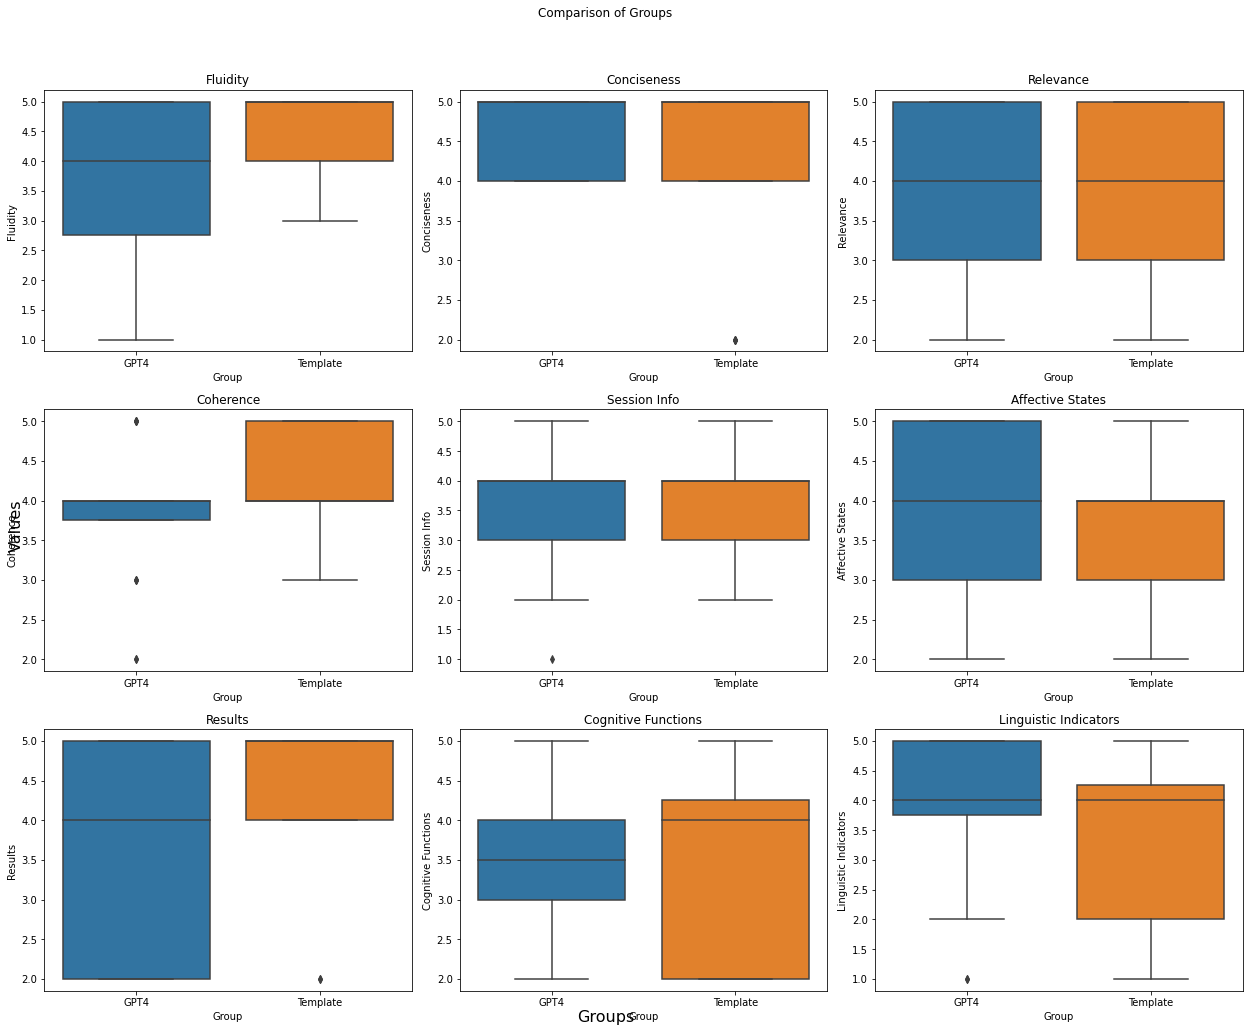

In [ ]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Set the columns to be used for the box plots
selected_columns = df_combined.columns[:-1]  # Exclude the 'Group' column

# Create the plot
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Comparison of Groups')

# Loop through each subplot
for i in range(3):
    for j in range(3):
        if i * 3 + j < len(selected_columns):  # Ensure we don't exceed the number of selected columns
            sns.boxplot(ax=axes[i, j], data=df_combined, x='Group', y=selected_columns[i * 3 + j])
            axes[i, j].set_title(selected_columns[i * 3 + j])  # Set the title for each subplot

# Set the overall x-axis label
fig.text(0.5, 0.04, 'Groups', ha='center', fontsize=16)

# Set the overall y-axis label
fig.text(0.04, 0.5, 'Values', va='center', rotation='vertical', fontsize=16)

plt.tight_layout(rect=[0.03, 0.03, 1, 0.95])  # Adjust layout to make room for the title and labels
plt.savefig('./Fig/Multi-plot_comparison.jpg')  # Save the plot
plt.show()  # Display the plot

IAA

In [333]:
df_v1_extracted

,R1Q1,R1Q2,R1Q3,R1Q4,R1Q5,R1Q6,R1Q7,R1Q8,R1Q9,R2Q1,...,R4Q9,R5Q1,R5Q2,R5Q3,R5Q4,R5Q5,R5Q6,R5Q7,R5Q8,R5Q9
1,4,5,4,4,4,3,5,3,4,4,...,4,4,5,5,5,4,5,5,4,4
2,5,5,3,5,4,2,5,2,1,4,...,4,4,4,4,4,4,4,5,2,2
4,4,2,2,3,3,4,4,4,3,5,...,4,3,2,3,3,3,3,4,3,3
5,4,5,2,5,4,3,2,2,1,2,...,1,5,5,3,4,2,2,2,2,1


In [334]:
df_v1_extracted_iaa = df_v1_extracted.transpose()

In [335]:
df_v2_extracted

,R1Q1,R1Q2,R1Q3,R1Q4,R1Q5,R1Q6,R1Q7,R1Q8,R1Q9,R2Q1,...,R4Q9,R5Q1,R5Q2,R5Q3,R5Q4,R5Q5,R5Q6,R5Q7,R5Q8,R5Q9
0,5,4,5,5,4,2,5,5,5,5,...,5,2,5,5,4,4,4,3,5,5
1,5,4,5,4,4,4,5,4,5,4,...,5,3,5,5,4,4,5,2,4,5
3,5,5,4,4,3,3,5,4,4,5,...,4,2,4,3,4,3,3,2,3,3
8,5,5,5,5,4,5,5,5,4,3,...,5,2,4,3,3,3,4,2,4,4


In [336]:
# function copied from corr_annotation_PSent.ipynb
def calculate_kappa_df(data):
    # Calculate pairwise Cohen's kappa for all combinations of annotators
    combinations_annotators = combinations(data.columns, 2)
    kappa_scores = {}

    for annotator_pair in combinations_annotators:
        annotator1, annotator2 = annotator_pair
        kappa = cohen_kappa_score(data[annotator1], data[annotator2], weights='linear') # quadratic
        kappa_scores[(annotator1, annotator2)] = kappa
        kappa_scores[(annotator2, annotator1)] = kappa  # Include reverse pair as well

    # Create a DataFrame from kappa scores
    kappa_df = pd.DataFrame(index=data.columns, columns=data.columns)

    for annotator1 in data.columns:
        for annotator2 in data.columns:
            if annotator1 == annotator2:
                kappa_df.loc[annotator1, annotator2] = 1.0
            else:
                kappa_df.loc[annotator1, annotator2] = kappa_scores[(annotator1, annotator2)]
    return kappa_df

In [337]:
df_v1_extracted_iaa

,1,2,4,5
R1Q1,4,5,4,4
R1Q2,5,5,2,5
R1Q3,4,3,2,2
R1Q4,4,5,3,5
R1Q5,4,4,3,4
R1Q6,3,2,4,3
R1Q7,5,5,4,2
R1Q8,3,2,4,2
R1Q9,4,1,3,1
R2Q1,4,4,5,2


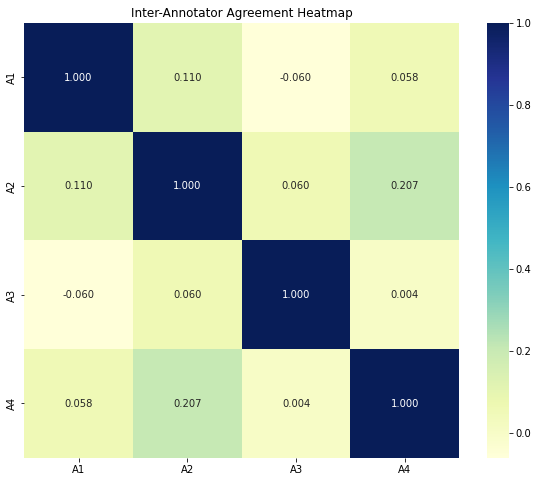

In [ ]:
df_v1_extracted_iaa.columns = ['A1', 'A2', 'A3', 'A4']

kappa_df = calculate_kappa_df(df_v1_extracted_iaa)
kappa_df

# Create a 4x4 heatmap for V1 annotators
plt.figure(figsize=(10, 8))
sns.heatmap(kappa_df.astype(float), annot=True, cmap="YlGnBu", fmt=".3f", square=True, cbar=True)
plt.title("Inter-Annotator Agreement Heatmap - V1 Survey")
plt.savefig('./Fig/IAA_annotators_v1.png')
plt.show()

In [ ]:
# IAA analysis for V2 survey
df_v2_extracted_iaa = df_v2_extracted.transpose()
df_v2_extracted_iaa.columns = ['A5', 'A6', 'A7', 'A8']

kappa_df_v2 = calculate_kappa_df(df_v2_extracted_iaa)

# Create a 4x4 heatmap for V2 annotators
plt.figure(figsize=(10, 8))
sns.heatmap(kappa_df_v2.astype(float), annot=True, cmap="YlGnBu", fmt=".3f", square=True, cbar=True)
plt.title("Inter-Annotator Agreement Heatmap - V2 Survey")
plt.savefig('./Fig/IAA_annotators_v2.png')
plt.show()

# Combined analysis summary
print(f"V1 Survey IAA - Mean Kappa: {kappa_df.values[kappa_df.values != 1.0].mean():.3f}")
print(f"V2 Survey IAA - Mean Kappa: {kappa_df_v2.values[kappa_df_v2.values != 1.0].mean():.3f}")
print(f"Total pairwise comparisons: V1={len(kappa_df.values[kappa_df.values != 1.0])}, V2={len(kappa_df_v2.values[kappa_df_v2.values != 1.0])}")